In [1]:
import random
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
from scipy import special
from tqdm import tqdm
from math import floor
import statsmodels.api as sm

# 5. Решение системы линейных уравнений с учетом погрешностей коэффициентов системы

In [23]:
# коэффициенты системы
A = np.array([
    [3, 2, -1],
    [2, -2, 4],
    [-1, 0.5, -1]
])
b = np.array([1, -2, 0])

x = np.linalg.solve(A, b)
x

array([ 1., -2., -2.])

Пусть $\delta = 0.05$ $-$ оценка сверху на модуль погрешности каждого коэффициента системы

In [35]:
delta = 0.05

Найдём решение доверительные интервалы решения системы уровня $Q=0.95$

In [34]:
Q=0.95

## 5.1. Монте-Карло

In [15]:
def generator_uniform(n):
    return np.random.uniform(-delta, delta, n)

In [4]:
def array_inaccuracied(array):
    inaccuracy = generator_uniform(array.size).reshape(array.shape)
    return array + inaccuracy

In [17]:
N = 10**3
solutions = []
for _ in range(N):
    solutions.append(
        np.linalg.solve(array_inaccuracied(A), array_inaccuracied(b))
    )
solutions = np.array(solutions)

In [20]:
np.min(solutions[:, 0])

np.float64(0.6611231328780078)

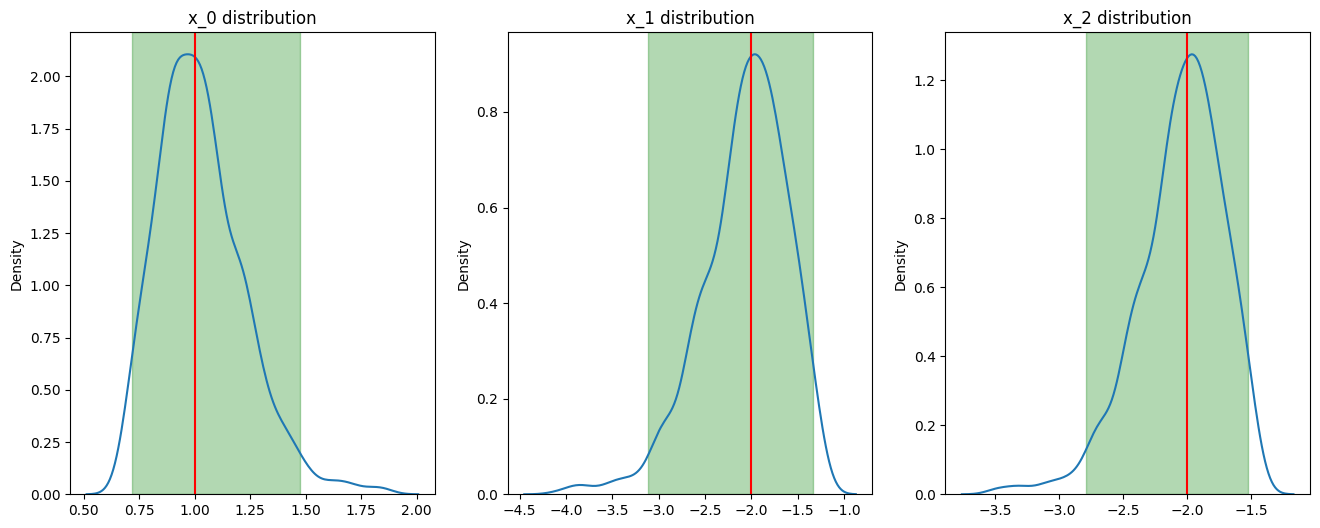

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for i in range(3):
    axes[i].set_title(f"x_{i} distribution")
    sns.kdeplot(solutions[:, i], ax=axes[i])

    axes[i].axvline(x[i], color = 'red')

    axes[i].axvspan(np.quantile(solutions[:, i], q=(1-Q)/2), np.quantile(solutions[:, i], q=(1+Q)/2), alpha=0.3, color='green', label=f'Confidence interval for x_{i}]')

In [42]:
pd.DataFrame(data={
    "left_bound" : [np.quantile(solutions[:, i], q=(1-Q)/2) for i in range(3)],
    "right_bound" : [np.quantile(solutions[:, i], q=(1+Q)/2) for i in range(3)]
}, index=["x_0", "x_1", "x_2"])

,left_bound,right_bound
x_0,0.719088,1.475582
x_1,-3.115168,-1.338676
x_2,-2.789932,-1.521455


## 5.2. Аналитическая формула

In [44]:
delta_x = np.linalg.solve(A, np.ones(3) * (-delta * 3)) # обобщение результата с лекции

left_bounds = x - np.abs(delta_x)
right_bounds = x + np.abs(delta_x)

pd.DataFrame(data={
    "left_bound" : left_bounds,
    "right_bound" : right_bounds
}, index=["x_0", "x_1", "x_2"])

,left_bound,right_bound
x_0,0.625,1.375
x_1,-3.000,-1.000
x_2,-2.725,-1.275
